In [3]:
import numpy as np
from pathlib import Path

from functions import *

from minerva.transforms.transform import *
from minerva.transforms.random_transform import *

from minerva.data.readers import TiffReader, PNGReader
from minerva.data.datasets import SimpleDataset
from minerva.data.data_modules import MinervaDataModule

from minerva.models.nets.image.deeplabv3 import DeepLabV3Backbone

from minerva.pipelines.lightning_pipeline import SimpleLightningPipeline
from lightning.pytorch.loggers.csv_logs import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning import Trainer

# Data

## Variables

In [13]:
REPETITION = 10
DATASET_NAME = 'f3'
BATCH_SIZE = 16
NUM_EPOCHS = 75
LEARNING_RATE = 0.001 
PRETRAIN_DATA = 'f3'
CAP = 1

In [11]:
f3_images_path = '/workspaces/shared_data/seismic/f3_segmentation/images'
f3_labels_path = '/workspaces/shared_data/seismic/f3_segmentation/annotations'
train_logs_path = f'logs/train/{REPETITION}'
train_ckpt_path = f'ckpt/train/{REPETITION}'

In [19]:
model_name = f'V{REPETITION}_pre_{PRETRAIN_DATA}_train_{DATASET_NAME}_cap_{CAP*100}%'
model_name

'V10_pre_f3_train_f3_cap_100%'

# Transforms

In [36]:
padding = Padding(256, 704)
cast_to_tensor = CastTo(dtype=np.float32)

finetune_pipeline = (
[
    padding,
    cast_to_tensor
    ]
)

# Image Visualization 

In [ ]:
tiff_reader = TiffReader(path = f3_images_path)
png_readder = PNGReader(path = f3_labels_path)

In [ ]:
image_example = tiff_reader[0]

label_example = png_readder[0]

padded_image = padding(image_example)
padded_label = padding(label_example)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


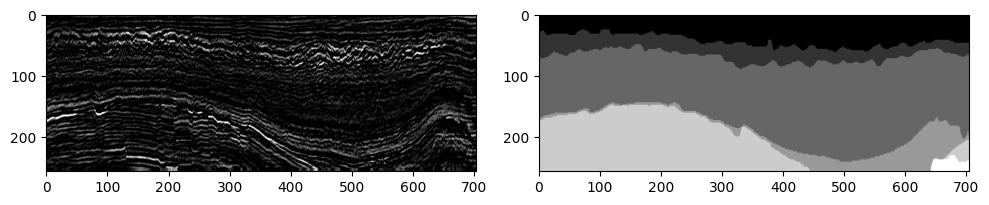

In [34]:
image_list = [
    transpose(padded_image),
    transpose(padded_label)
]
plot_images(image_list)

# Dataset

In [38]:
data_reader = TiffReader(path=f3_images_path)
labels_reader = PNGReader(path=f3_labels_path)

finetune_dataset = SimpleDataset(
    readers=[data_reader, labels_reader],
    transforms=finetune_pipeline,
)

# DataModule

In [39]:
data_module = MinervaDataModule(
    train_dataset=finetune_dataset,
    batch_size=BATCH_SIZE,
    shuffle_train=True,
    name=DATASET_NAME
)

# Model